<a href="https://colab.research.google.com/github/bvsvarshini/ds_varshini/blob/main/notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
trades = pd.read_csv("csv_files/historical_data.csv")
sentiment = pd.read_csv("csv_files/fear_greed_index.csv")


In [ ]:
print(trades.head())
print(trades.info())

print(sentiment.head())
print(sentiment.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)
trades['trade_date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    dayfirst=True,
    errors='coerce'
)
sentiment['sentiment_date'] = sentiment['date'].dt.date

In [ ]:
btc_trades = trades[trades['Coin'].str.contains('BTC', case=False)].copy()


In [ ]:
btc_trades['is_profitable'] = btc_trades['Closed PnL'] > 0
btc_trades['pnl_ratio'] = btc_trades['Closed PnL'] / btc_trades['Size USD']

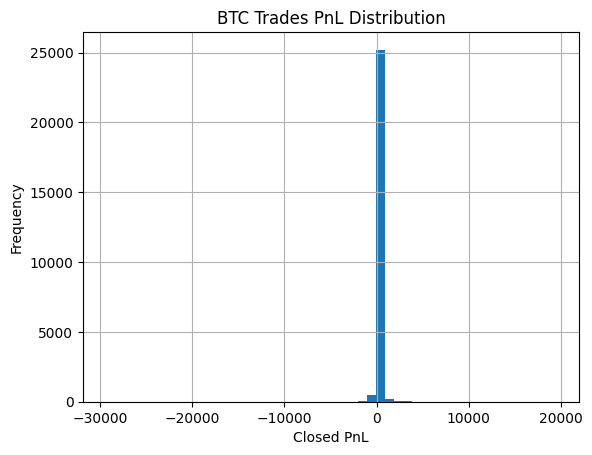

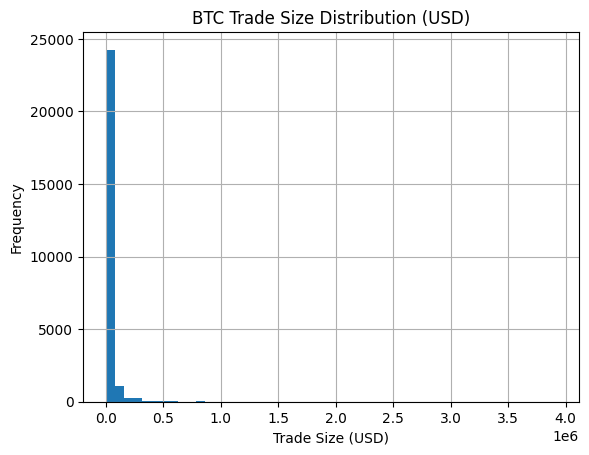

In [ ]:
import os

# Ensure the outputs folder exists
os.makedirs("outputs", exist_ok=True)

plt.figure()
btc_trades['Closed PnL'].hist(bins=50)
plt.title("BTC Trades PnL Distribution")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("outputs/btc_pnl_distribution.png", dpi=300, bbox_inches="tight")  # Safe now
plt.show()

plt.figure()
btc_trades['Size USD'].hist(bins=50)
plt.title("BTC Trade Size Distribution (USD)")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("outputs/btc_trade_size_distribution.png", dpi=300, bbox_inches="tight")  # Safe now
plt.show()
